<a href="https://colab.research.google.com/github/crisalexps/Challange.X2/blob/main/ChallangeX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Extracción del archivo Tratado

In [1]:
import pandas as pd


In [2]:
datos = pd.read_csv('/content/telecom_churn_limpio (2).csv')

In [3]:
datos.head()

,date,consumption,wind,solar,wind_solar,churn,facturacion_mensual,cuentas_diarias,segmento_consumo,nivel_consumo,tipo_cliente
0,2012-01-01,948.128,227.465,6.587,234.052,1,948.128,31.604267,Bajo,Bajo,Mixto
1,2012-01-02,1269.581,207.327,6.574,213.901,1,1269.581,42.319367,Medio,Medio,Mixto
2,2012-01-03,1334.745,473.468,24.679,498.147,1,1334.745,44.491500,Medio,Medio,Mixto
3,2012-01-04,1347.136,499.804,14.681,514.485,1,1347.136,44.904533,Medio,Medio,Mixto
4,2012-01-05,1376.658,523.851,5.071,528.922,1,1376.658,45.888600,Alto,Alto,Mixto


##Eliminacion de Columnas Irrelevantes

In [4]:
datos.columns


Index(['date', 'consumption', 'wind', 'solar', 'wind_solar', 'churn',
       'facturacion_mensual', 'cuentas_diarias', 'segmento_consumo',
       'nivel_consumo', 'tipo_cliente'],
      dtype='object')

In [5]:
columnas_irrelevantes = [
    'wind_solar',          # redundante (wind + solar)
    'facturacion_mensual', # duplicada de consumption
    'cuentas_diarias',     # variable derivada
    'segmento_consumo'     # redundante con nivel_consumo
]

In [6]:
datos = datos.drop(columns=columnas_irrelevantes)


In [7]:
datos.columns


Index(['date', 'consumption', 'wind', 'solar', 'churn', 'nivel_consumo',
       'tipo_cliente'],
      dtype='object')

In [8]:
datos = datos.drop(columns=columnas_irrelevantes, errors='ignore')


In [9]:
datos.head()

,date,consumption,wind,solar,churn,nivel_consumo,tipo_cliente
0,2012-01-01,948.128,227.465,6.587,1,Bajo,Mixto
1,2012-01-02,1269.581,207.327,6.574,1,Medio,Mixto
2,2012-01-03,1334.745,473.468,24.679,1,Medio,Mixto
3,2012-01-04,1347.136,499.804,14.681,1,Medio,Mixto
4,2012-01-05,1376.658,523.851,5.071,1,Alto,Mixto


In [10]:
datos.select_dtypes(include='object').columns


Index(['date', 'nivel_consumo', 'tipo_cliente'], dtype='object')

In [11]:
datos_encoded = pd.get_dummies(
    datos,
    columns=['nivel_consumo', 'tipo_cliente'],
    drop_first=True
)


In [12]:
datos_encoded.head()


,date,consumption,wind,solar,churn,nivel_consumo_Bajo,nivel_consumo_Medio,nivel_consumo_Muy Alto
0,2012-01-01,948.128,227.465,6.587,1,True,False,False
1,2012-01-02,1269.581,207.327,6.574,1,False,True,False
2,2012-01-03,1334.745,473.468,24.679,1,False,True,False
3,2012-01-04,1347.136,499.804,14.681,1,False,True,False
4,2012-01-05,1376.658,523.851,5.071,1,False,False,False


##Proporcion de cancelación(churn)

In [13]:
conteo_clases = datos['churn'].value_counts()
conteo_clases


,count
churn,
0,1094
1,1093


In [14]:
X = datos.drop(columns='churn')
y = datos['churn']


In [15]:
proporcion_clases = datos['churn'].value_counts(normalize=True)
proporcion_clases


,proportion
churn,
0,0.500229
1,0.499771


In [16]:
(proporcion_clases * 100).round(2)


,proportion
churn,
0,50.02
1,49.98


##Identificando columnas categoricas

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_features = ['nivel_consumo', 'tipo_cliente']
num_features = X.select_dtypes(exclude='object').columns


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
        ('num', 'passthrough', num_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)


In [19]:
X_encoded[:5]


array([[1.000000e+00, 0.000000e+00, 0.000000e+00, 9.481280e+02,
        2.274650e+02, 6.587000e+00],
       [0.000000e+00, 1.000000e+00, 0.000000e+00, 1.269581e+03,
        2.073270e+02, 6.574000e+00],
       [0.000000e+00, 1.000000e+00, 0.000000e+00, 1.334745e+03,
        4.734680e+02, 2.467900e+01],
       [0.000000e+00, 1.000000e+00, 0.000000e+00, 1.347136e+03,
        4.998040e+02, 1.468100e+01],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, 1.376658e+03,
        5.238510e+02, 5.071000e+00]])

In [20]:
feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_features)
)

columnas_finales = list(feature_names) + list(num_features)


In [21]:
import pandas as pd
X_encoded = pd.DataFrame(X_encoded, columns=columnas_finales)
X_encoded.head()


,nivel_consumo_Bajo,nivel_consumo_Medio,nivel_consumo_Muy Alto,consumption,wind,solar
0,1.0,0.0,0.0,948.128,227.465,6.587
1,0.0,1.0,0.0,1269.581,207.327,6.574
2,0.0,1.0,0.0,1334.745,473.468,24.679
3,0.0,1.0,0.0,1347.136,499.804,14.681
4,0.0,0.0,0.0,1376.658,523.851,5.071


In [22]:
datos['date'] = pd.to_datetime(datos['date'])
datos['year'] = datos['date'].dt.year
datos['month'] = datos['date'].dt.month
datos['dayofweek'] = datos['date'].dt.dayofweek

datos = datos.drop(columns='date')


Balanceo de clases

In [23]:
X = X_encoded
y = datos['churn']


In [24]:
y.value_counts(normalize=True) * 100


,proportion
churn,
0,50.022862
1,49.977138


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


In [26]:
y_res.value_counts(normalize=True) * 100


,proportion
churn,
1,50.0
0,50.0


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


##Normalización y estandarización

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

##Analisis de Correlacion

In [31]:
import pandas as pd

datos_numericos = datos.select_dtypes(include=['int64', 'float64'])


In [32]:
matriz_correlacion = datos_numericos.corr()
matriz_correlacion


,consumption,wind,solar,churn
consumption,1.000000,0.133076,-0.279543,-0.808578
wind,0.133076,1.000000,-0.308832,-0.077143
solar,-0.279543,-0.308832,1.000000,0.154464
churn,-0.808578,-0.077143,0.154464,1.000000


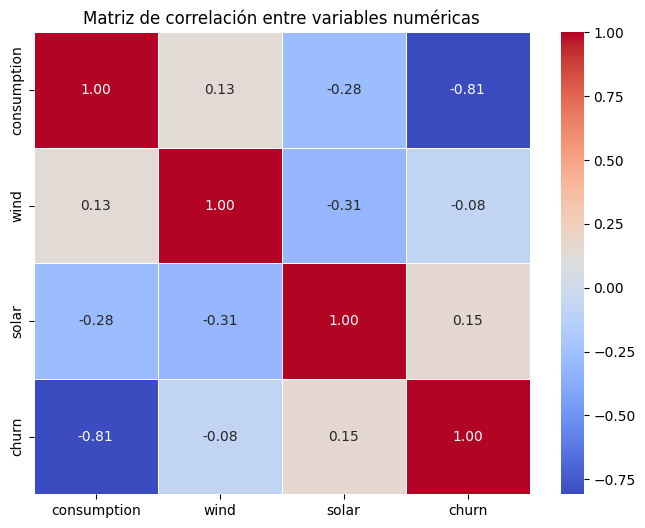

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


In [34]:
matriz_correlacion['churn'].sort_values(ascending=False)


,churn
churn,1.000000
solar,0.154464
wind,-0.077143
consumption,-0.808578


Analisis Dirigido

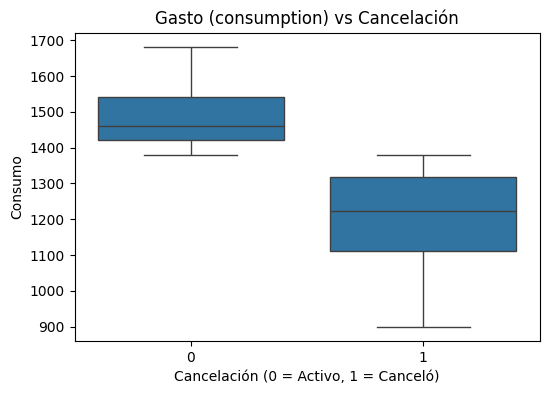

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(data=datos, x='churn', y='consumption')
plt.title('Gasto (consumption) vs Cancelación')
plt.xlabel('Cancelación (0 = Activo, 1 = Canceló)')
plt.ylabel('Consumo')
plt.show()


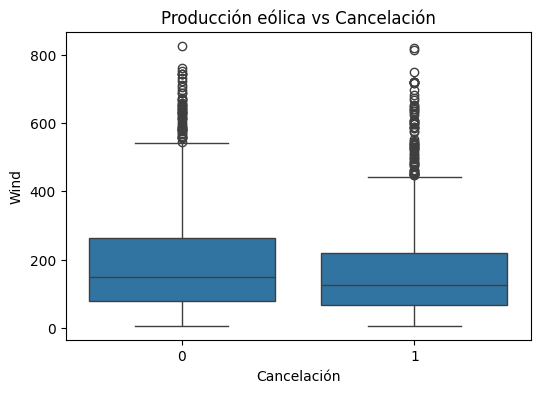

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(data=datos, x='churn', y='wind')
plt.title('Producción eólica vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Wind')
plt.show()


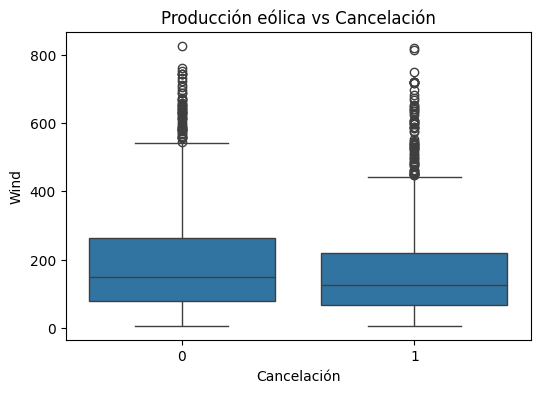

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(data=datos, x='churn', y='wind')
plt.title('Producción eólica vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Wind')
plt.show()


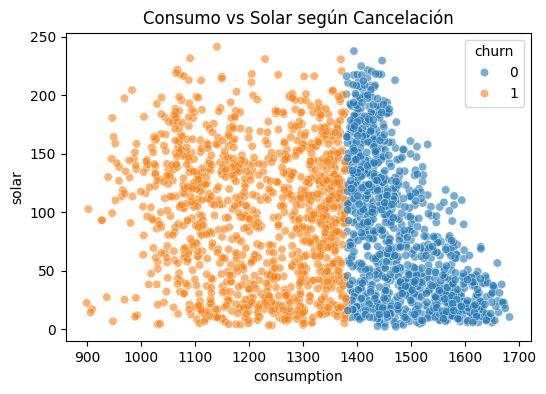

In [38]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=datos,
    x='consumption',
    y='solar',
    hue='churn',
    alpha=0.6
)
plt.title('Consumo vs Solar según Cancelación')
plt.show()


##Separacion de datos

In [39]:
X = X_encoded   # variables independientes
y = datos['churn']  # variable objetivo


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [41]:
X_train.shape, X_test.shape


((1749, 6), (438, 6))

##Evaluación de Modelo



In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd


In [43]:
modelo_logistico = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])


In [44]:
modelo_logistico.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [45]:
y_pred_lr = modelo_logistico.predict(X_test)


In [46]:
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("REGRESIÓN LOGÍSTICA")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1:", f1_lr)
print("Matriz de Confusión:\n", cm_lr)
print(classification_report(y_test, y_pred_lr))


REGRESIÓN LOGÍSTICA
Accuracy: 0.997716894977169
Precision: 1.0
Recall: 0.9954337899543378
F1: 0.9977116704805492
Matriz de Confusión:
 [[219   0]
 [  1 218]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      1.00      1.00       219

    accuracy                           1.00       438
   macro avg       1.00      1.00      1.00       438
weighted avg       1.00      1.00      1.00       438



In [47]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)


In [48]:
modelo_rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [49]:
y_pred_rf = modelo_rf.predict(X_test)


In [50]:
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("RANDOM FOREST")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1:", f1_rf)
print("Matriz de Confusión:\n", cm_rf)
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Matriz de Confusión:
 [[219   0]
 [  0 219]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      1.00      1.00       219

    accuracy                           1.00       438
   macro avg       1.00      1.00      1.00       438
weighted avg       1.00      1.00      1.00       438



In [51]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1-score': [f1_lr, f1_rf]
})

resultados


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.997717,1.0,0.995434,0.997712
1,Random Forest,1.000000,1.0,1.000000,1.000000


##Analisis de la importancia de las variables

En el modelo KNN no existen coeficientes explícitos. La relevancia de las variables se evaluó mediante Permutation Importance, analizando cómo la permutación de cada variable afecta el desempeño del modelo. Las variables con mayor caída en la métrica son las que más influyen en la proximidad entre observaciones y, por lo tanto, en la clasificación de la cancelación.

In [52]:
import pandas as pd

coeficientes_lr = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo_logistico.named_steps['logistic'].coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

coeficientes_lr


,Variable,Coeficiente
3,consumption,-9.669072
1,nivel_consumo_Medio,1.312290
5,solar,-0.173610
4,wind,0.126564
2,nivel_consumo_Muy Alto,-0.067075
0,nivel_consumo_Bajo,-0.007447


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
import pandas as pd


In [54]:
modelo_knn = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

modelo_knn.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [55]:
result_knn = permutation_importance(
    modelo_knn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


In [56]:
importancias_knn = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': result_knn.importances_mean
}).sort_values(by='Importancia', ascending=False)

importancias_knn


,Variable,Importancia
3,consumption,0.154110
0,nivel_consumo_Bajo,0.072603
1,nivel_consumo_Medio,0.063242
2,nivel_consumo_Muy Alto,0.004566
5,solar,0.000000
4,wind,-0.000228


In [57]:
!zip -r entrega_churn.zip .


  adding: .config/ (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.01.16/ (stored 0%)
  adding: .config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
  adding: .config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
  adding: .config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)
  adding: .config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
  adding: .config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
  adding: .config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
  adding: .config/active_config (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/.last_update_check.json (deflated 22%)
  adding: .config/config_

In [58]:
from google.colab import files
files.download("entrega_churn.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
!git add . && git commit -m "Entrega final churn prediction" && git push origin main


fatal: not a git repository (or any of the parent directories): .git
